In [2]:
import pandas as pd

In [3]:
df_accounts = pd.read_csv("../data/raw/ravenstack_accounts.csv")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df_accounts = pd.read_csv("../data/raw/ravenstack_accounts.csv")
df_subscriptions = pd.read_csv("../data/raw/ravenstack_subscriptions.csv")
df_feature_usage = pd.read_csv("../data/raw/ravenstack_feature_usage.csv")
df_support = pd.read_csv("../data/raw/ravenstack_support_tickets.csv")
df_churn = pd.read_csv("../data/raw/ravenstack_churn_events.csv")

In [6]:
df_accounts['signup_date'] = pd.to_datetime(df_accounts['signup_date'])
df_subscriptions['start_date'] = pd.to_datetime(df_subscriptions['start_date'])
df_subscriptions['end_date'] = pd.to_datetime(df_subscriptions['end_date'])
df_feature_usage['usage_date'] = pd.to_datetime(df_feature_usage['usage_date'])
df_support['submitted_at'] = pd.to_datetime(df_support['submitted_at'])
df_support['closed_at'] = pd.to_datetime(df_support['closed_at'])
df_churn['churn_date'] = pd.to_datetime(df_churn['churn_date'])

In [7]:
print("All tables loaded and dates converted.")

All tables loaded and dates converted.


In [8]:
revenue_by_tier = df_subscriptions.groupby('plan_tier')['mrr_amount'].sum().sort_values(ascending=False)
print(revenue_by_tier)

plan_tier
Enterprise    8473221
Pro           2105089
Basic          760437
Name: mrr_amount, dtype: int64


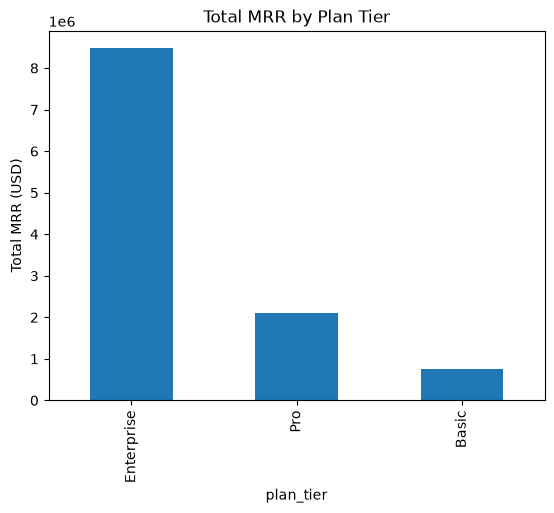

In [9]:
revenue_by_tier.plot(kind='bar', title='Total MRR by Plan Tier', ylabel='Total MRR (USD)')
plt.show()

In [10]:
reference_date = pd.Timestamp("2024-12-31")
df_accounts['tenure_days'] = (reference_date - df_accounts['signup_date']).dt.days
df_accounts[['account_id', 'signup_date', 'tenure_days', 'churn_flag']].head()

,account_id,signup_date,tenure_days,churn_flag
0,A-2e4581,2024-10-16,76,False
1,A-43a9e3,2023-08-17,502,True
2,A-0a282f,2024-08-27,126,False
3,A-1f0ac7,2023-08-27,492,False
4,A-ce550d,2024-10-27,65,True


In [11]:
df_accounts.groupby('churn_flag')['tenure_days'].mean()

churn_flag
False    329.433333
True     371.672727
Name: tenure_days, dtype: float64

In [12]:
df_accounts.groupby('churn_flag')['tenure_days'].mean()

churn_flag
False    329.433333
True     371.672727
Name: tenure_days, dtype: float64

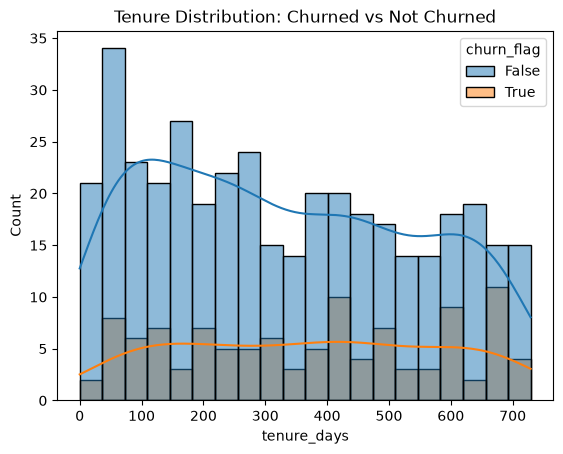

In [13]:
sns.histplot(data=df_accounts, x='tenure_days', hue='churn_flag', bins=20, kde=True)
plt.title('Tenure Distribution: Churned vs Not Churned')
plt.show()

In [14]:
usage_per_subscription = df_feature_usage.groupby('subscription_id')['usage_count'].sum().reset_index()
usage_per_subscription.head()

,subscription_id,usage_count
0,S-001561,48
1,S-0027d3,44
2,S-003647,71
3,S-003fc0,43
4,S-004d19,18


In [15]:
# Step 2a: bring account_id into the usage data via subscription_id
usage_with_account = usage_per_subscription.merge(
    df_subscriptions[['subscription_id', 'account_id']],
    on='subscription_id',
    how='left'
)
usage_with_account.head()

,subscription_id,usage_count,account_id
0,S-001561,48,A-1b7577
1,S-0027d3,44,A-e693b6
2,S-003647,71,A-e36807
3,S-003fc0,43,A-65c341
4,S-004d19,18,A-bece89


In [16]:
usage_per_account = usage_with_account.groupby('account_id')['usage_count'].sum().reset_index()

usage_with_churn = usage_per_account.merge(
    df_accounts[['account_id', 'churn_flag']],
    on='account_id',
    how='left'
)
usage_with_churn.head()

,account_id,usage_count,churn_flag
0,A-00bed1,514,False
1,A-00cac8,602,False
2,A-0158bb,364,False
3,A-016043,490,False
4,A-019782,562,False


In [17]:
usage_per_account = usage_with_account.groupby('account_id')['usage_count'].sum().reset_index()

usage_with_churn = usage_per_account.merge(
    df_accounts[['account_id', 'churn_flag']],
    on='account_id',
    how='left'
)
usage_with_churn.head()

,account_id,usage_count,churn_flag
0,A-00bed1,514,False
1,A-00cac8,602,False
2,A-0158bb,364,False
3,A-016043,490,False
4,A-019782,562,False


In [18]:
usage_with_churn.groupby('churn_flag')['usage_count'].mean()

churn_flag
False    495.130769
True     522.036364
Name: usage_count, dtype: float64

In [19]:
support_per_account = df_support.groupby('account_id').agg(
    ticket_count=('ticket_id', 'count'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    escalation_rate=('escalation_flag', 'mean')
).reset_index()
support_per_account.head()

,account_id,ticket_count,avg_satisfaction,escalation_rate
0,A-00bed1,4,4.0,0.0
1,A-00cac8,2,NaN,0.0
2,A-0158bb,1,3.0,0.0
3,A-016043,3,4.0,0.0
4,A-019782,2,3.0,0.0


In [20]:
support_with_churn = support_per_account.merge(
    df_accounts[['account_id', 'churn_flag']],
    on='account_id',
    how='left'
)

support_with_churn.groupby('churn_flag')[['ticket_count', 'avg_satisfaction', 'escalation_rate']].mean()

,ticket_count,avg_satisfaction,escalation_rate
churn_flag,,,
False,4.083333,3.953395,0.044033
True,4.000000,4.002591,0.062147


In [21]:
# Active accounts = those without churn_flag = True
active_accounts = df_accounts[df_accounts['churn_flag'] == False]

# Get their current MRR from subscriptions (most recent/active subscription)
active_subs = df_subscriptions[df_subscriptions['end_date'].isnull()]  # still-active subscriptions

active_value = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()

at_risk = active_accounts.merge(active_value, on='account_id', how='inner')
at_risk = at_risk.merge(support_with_churn[['account_id','escalation_rate']], on='account_id', how='left')

at_risk_sorted = at_risk[['account_id', 'account_name', 'industry', 'mrr_amount', 'escalation_rate']].sort_values('mrr_amount', ascending=False)
at_risk_sorted.head(10)

,account_id,account_name,industry,mrr_amount,escalation_rate
123,A-5b1bcd,Company_166,DevTools,131911,0.000000
308,A-d4e0d4,Company_403,FinTech,114777,0.000000
279,A-1f0636,Company_368,EdTech,94710,0.000000
96,A-5c046d,Company_130,EdTech,83886,0.000000
380,A-18793f,Company_488,EdTech,75776,0.000000
374,A-c58f49,Company_480,EdTech,70980,0.333333
258,A-09316c,Company_341,FinTech,70000,0.250000
271,A-5a215a,Company_358,EdTech,69687,0.000000
130,A-fa3095,Company_174,FinTech,69230,0.000000
369,A-e08cd3,Company_475,FinTech,67737,0.000000


In [22]:
import pandas as pd

df_accounts = pd.read_csv("../data/raw/ravenstack_accounts.csv")
df_subscriptions = pd.read_csv("../data/raw/ravenstack_subscriptions.csv")
df_feature_usage = pd.read_csv("../data/raw/ravenstack_feature_usage.csv")
df_support = pd.read_csv("../data/raw/ravenstack_support_tickets.csv")
df_churn = pd.read_csv("../data/raw/ravenstack_churn_events.csv")

print("Raw data loaded.")


Raw data loaded.


In [24]:
df_accounts['signup_date'] = pd.to_datetime(df_accounts['signup_date'])

df_subscriptions['start_date'] = pd.to_datetime(df_subscriptions['start_date'])
df_subscriptions['end_date'] = pd.to_datetime(df_subscriptions['end_date'])

df_feature_usage['usage_date'] = pd.to_datetime(df_feature_usage['usage_date'])

df_support['submitted_at'] = pd.to_datetime(df_support['submitted_at'])
df_support['closed_at'] = pd.to_datetime(df_support['closed_at'])

df_churn['churn_date'] = pd.to_datetime(df_churn['churn_date'])

print("All date columns converted.")

All date columns converted.


In [25]:
df_accounts.dtypes

account_id                    str
account_name                  str
industry                      str
country                       str
signup_date        datetime64[us]
referral_source               str
plan_tier                     str
seats                       int64
is_trial                     bool
churn_flag                   bool
dtype: object

In [26]:
df_subscriptions['is_active'] = df_subscriptions['end_date'].isnull()
df_subscriptions[['subscription_id', 'start_date', 'end_date', 'is_active']].head()

,subscription_id,start_date,end_date,is_active
0,S-8cec59,2023-12-23,2024-04-12,False
1,S-0f6f44,2024-06-11,NaT,True
2,S-51c0d1,2024-11-25,NaT,True
3,S-f81687,2024-11-23,2024-12-13,False
4,S-cff5a2,2024-01-10,NaT,True


In [27]:
print("Negative MRR count:", (df_subscriptions['mrr_amount'] < 0).sum())
print("Zero or negative seats:", (df_subscriptions['seats'] <= 0).sum())
print("End date before start date:", (df_subscriptions['end_date'] < df_subscriptions['start_date']).sum())

Negative MRR count: 0
Zero or negative seats: 0
End date before start date: 0


In [28]:
print("Zero or negative seats (accounts):", (df_accounts['seats'] <= 0).sum())
print("Negative refund amount:", (df_churn['refund_amount_usd'] < 0).sum())
print("Churn date before signup date - checking via merge:")

check = df_churn.merge(df_accounts[['account_id', 'signup_date']], on='account_id', how='left')
print("Churn events before signup:", (check['churn_date'] < check['signup_date']).sum())

Zero or negative seats (accounts): 0
Negative refund amount: 0
Churn date before signup date - checking via merge:
Churn events before signup: 0


In [29]:
df_accounts.to_csv("../data/processed/accounts_clean.csv", index=False)
df_subscriptions.to_csv("../data/processed/subscriptions_clean.csv", index=False)
df_feature_usage.to_csv("../data/processed/feature_usage_clean.csv", index=False)
df_support.to_csv("../data/processed/support_tickets_clean.csv", index=False)
df_churn.to_csv("../data/processed/churn_events_clean.csv", index=False)

print("Cleaned data saved to data/processed/")

Cleaned data saved to data/processed/
